In [22]:
import nbformat
import glob

# === Настройки ===
# Укажи путь к файлу или папке, где лежит твой notebook (.ipynb)
notebook_path = "/content/composantMatch.ipynb"  # замени на свой путь

# === Исправление одного файла ===
nb = nbformat.read(notebook_path, as_version=4)

if "widgets" in nb.metadata:
    print("🧹 Найден блок metadata.widgets — удаляю...")
    del nb.metadata["widgets"]
    nbformat.write(nb, notebook_path)
    print("✅ Исправлено и сохранено:", notebook_path)
else:
    print("✅ Ошибочный блок не найден — всё уже в порядке.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/composantMatch.ipynb'

In [1]:
# === Notebook: ComponentMatch ===

# 0) Install required libraries
!pip install -q sentence-transformers faiss-cpu datasets transformers accelerate gradio pandas tqdm
# 1) Imports
import os
import io
import sys
import json
import time
import math
import urllib.request
from pathlib import Path
from typing import List, Dict, Tuple, Any

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import faiss
from sentence_transformers import SentenceTransformer

from datasets import load_dataset

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [2]:
# 2) Configurations
CFG = {

    "cosmetics_raw_url": "https://raw.githubusercontent.com/VazquezJocelyn/Cosmetic-Price-Analysis/main/cosmetics.csv",
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "llm_model": "google/flan-t5-base",  # used for normalization, query rewrite, explanations
    "top_k": 10,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "random_seed": 42
}

np.random.seed(CFG["random_seed"])
torch.manual_seed(CFG["random_seed"])

print("Configuration:", CFG)


Configuration: {'cosmetics_raw_url': 'https://raw.githubusercontent.com/VazquezJocelyn/Cosmetic-Price-Analysis/main/cosmetics.csv', 'embedding_model': 'sentence-transformers/all-MiniLM-L6-v2', 'llm_model': 'google/flan-t5-base', 'top_k': 10, 'device': 'cuda', 'random_seed': 42}


In [3]:
# 3) Download / load datasets / data cleaning
def load_cosmetics_dataset(raw_url: str) -> pd.DataFrame:
    print("Downloading cosmetics CSV from GitHub...")
    out_path = "cosmetics.csv"
    urllib.request.urlretrieve(raw_url, out_path)
    df = pd.read_csv(out_path)
    # Attempt to find product name and ingredients columns
    possible_name_cols = [c for c in df.columns if "name" in c.lower() or "product" in c.lower()]
    possible_ing_cols = [c for c in df.columns if "ingredient" in c.lower()]
    name_col = possible_name_cols[0] if possible_name_cols else df.columns[0]
    ing_col = possible_ing_cols[0] if possible_ing_cols else df.columns[1] if len(df.columns)>1 else df.columns[0]
    out = pd.DataFrame({
        "product_name": df[name_col].fillna("unknown").astype(str),
        "ingredients_raw": df[ing_col].fillna("").astype(str)
    })
    out["domain"] = "cosmetics"
    print("Loaded cosmetics rows:", len(out))
    return out

# Load datasets
df = load_cosmetics_dataset(CFG["cosmetics_raw_url"])

df.head(5)

Loaded cosmetics rows: 1472


,product_name,ingredients_raw,domain
0,Crème de la Mer,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",cosmetics
1,Facial Treatment Essence,"Galactomyces Ferment Filtrate (Pitera), Butyle...",cosmetics
2,Protini™ Polypeptide Cream,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",cosmetics
3,The Moisturizing Soft Cream,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",cosmetics
4,Your Skin But Better™ CC+™ Cream with SPF 50+,"Water, Snail Secretion Filtrate, Phenyl Trimet...",cosmetics


In [4]:
# remove empties + long strings
MAX_CHARS = 1500
df = df.copy()
df = df[df["ingredients_raw"].notnull()].copy()
df["ingredients_raw"] = df["ingredients_raw"].fillna("").astype(str)
df = df[df["ingredients_raw"].str.strip() != ""].copy()
df = df[df["ingredients_raw"].str.len() < MAX_CHARS].copy()
df.reset_index(drop=True, inplace=True)
print("After cleaning:", df.shape)

After cleaning: (1380, 3)


In [5]:
# 4) Preprocessing functions (rule-based normalization)
import re
_token_split_re = re.compile(r"[,\n;/\(\)\[\]\|]+")

def rule_normalize_ingredients(text: str) -> str:
    """Lowercase, remove symbols, split, deduplicate."""
    if not isinstance(text, str):
        return ""
    s = text.lower()
    # keep only letters, digits and a few separators
    s = re.sub(r"[^a-z0-9,;\-\.\s\(\)/]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    parts = [p.strip() for p in _token_split_re.split(s) if p.strip()]
    parts = [p for p in parts if len(p) > 1]

    seen, uniq = set(), []
    for p in parts:
        if p not in seen:
            uniq.append(p)
            seen.add(p)
    return ", ".join(uniq)

df["ingredients_rule_norm"] = df["ingredients_raw"].apply(rule_normalize_ingredients)

df.head(5)

,product_name,ingredients_raw,domain,ingredients_rule_norm
0,Crème de la Mer,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",cosmetics,"algae, seaweed, extract, mineral oil, petrolat..."
1,Facial Treatment Essence,"Galactomyces Ferment Filtrate (Pitera), Butyle...",cosmetics,"galactomyces ferment filtrate, pitera, butylen..."
2,Protini™ Polypeptide Cream,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",cosmetics,"water, dicaprylyl carbonate, glycerin, ceteary..."
3,The Water Cream,"Water, Saccharomyces/Camellia Sinensis Leaf/Cl...",cosmetics,"water, saccharomyces, camellia sinensis leaf, ..."
4,Lala Retro™ Whipped Cream,"Water, Glycerin, Caprylic/ Capric Triglyceride...",cosmetics,"water, glycerin, caprylic, capric triglyceride..."


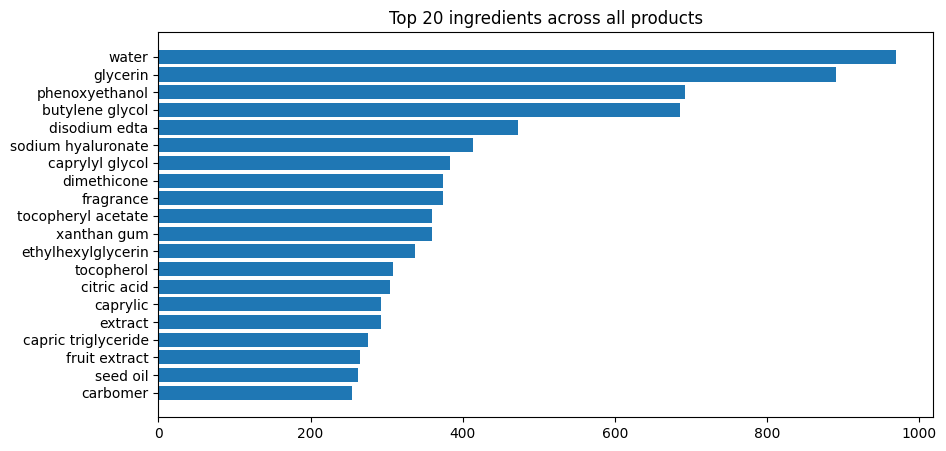

In [6]:
import matplotlib.pyplot as plt

# Top 20 ingredients frequency (rule-based)
from collections import Counter
all_tokens = []
for ing in df['ingredients_rule_norm']:
    all_tokens.extend([t.strip() for t in ing.split(',') if t.strip()])
common_ing = Counter(all_tokens).most_common(20)
labels, values = zip(*common_ing)
plt.figure(figsize=(10,5))
plt.barh(labels[::-1], values[::-1])
plt.title('Top 20 ingredients across all products')
plt.show()


In [7]:
# 5) Setup embedding model (sentence-transformers)
print("Loading embedding model:", CFG["embedding_model"])
embed_model = SentenceTransformer(CFG["embedding_model"], device=CFG["device"])

def embed_texts(texts: List[str], batch_size: int = 64) -> np.ndarray:
    embs = embed_model.encode(texts, show_progress_bar=True, batch_size=batch_size, convert_to_numpy=True)
    return embs

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
def safe_truncate(text, tokenizer, max_len=400):
    """
    Truncate text to a safe length for the tokenizer.
    max_len = number of words (rough approximation).
    """
    tokens = text.split()
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
    return " ".join(tokens)


In [9]:
# 6) LLM model (Flan-T5) for normalization, query rewrite, explanations
print("Loading LLM (seq2seq) for normalization & explanations:", CFG["llm_model"])
tokenizer = AutoTokenizer.from_pretrained(CFG["llm_model"], use_fast=True)
llm = AutoModelForSeq2SeqLM.from_pretrained(CFG["llm_model"]).to(CFG["device"])

# helper pipeline for generation
gen_pipeline = pipeline("text2text-generation", model=llm, tokenizer=tokenizer, device=0 if CFG["device"].startswith("cuda") else -1)

# Few-shot prompt templates
NORM_PROMPT_PREFIX = (
    "Normalize this ingredient list into canonical English ingredient names separated by commas. "
    "Replace synonyms (e.g., 'aqua' -> 'water', 'tocopherol acetate' -> 'tocopherol') and remove irrelevant words. "
    "Return only a comma-separated list.\n\nExamples:\n"
    "Input: 'Aqua, Glycerin, Butyrospermum Parkii (Shea Butter), Phenoxyethanol.'\n"
    "Output: 'water, glycerin, Butyrospermum Parkii/shea butter, phenoxyethanol'\n\n"
)

REWRITE_PROMPT_PREFIX = (
    "Rewrite and expand this ingredient query to include common synonyms and canonical forms, preserving the meaning. "
    "Return a short comma-separated expanded ingredient list.\n\nExamples:\n"
    "Input: 'aqua, glycerin, shea butter'\n"
    "Output: 'water/aqua, glycerin, shea butter/butyrospermum parkii'\n\n"
)

EXPLAIN_PROMPT_PREFIX = (
    "Mention ONLY the ingredients that exactly match between them. "
    "DO NOT invent relations, DO NOT explain biology or chemistry."
    "Example:\nQuery: '{query}'\nCandidate: '{candidate}'\nOutput:This was chosen because ..."
    "Do not infer or explain relationships. "
    "Begin with a small intro sentence like this product has been chosen because... small explaination"
)

def llm_normalize_list(text: str, max_length: int = 128) -> str:
    if not text or len(text.strip())==0:
        return ""
    text = safe_truncate(text, tokenizer, max_len=400)
    prompt = NORM_PROMPT_PREFIX + f"Input: '{text}'\nOutput:"
    #out = gen_pipeline(prompt, max_length=max_length, do_sample=False)[0]["generated_text"]
    out = gen_pipeline(prompt, max_new_tokens=max_length, do_sample=False)[0]["generated_text"]
    # post-clean: keep only lower-case tokens and commas
    out = out.strip()
    out = re.sub(r"\s+", " ", out)
    out = out.lower()
    # remove trailing punctuation
    out = out.strip(" .")
    return out

def llm_rewrite_query(text: str, max_length: int = 128) -> str:
    if not text or len(text.strip())==0:
        return ""
    text = safe_truncate(text, tokenizer, max_len=400)
    prompt = REWRITE_PROMPT_PREFIX + f"Input: '{text}'\nOutput:"
    #out = gen_pipeline(prompt, max_length=max_length, do_sample=False)[0]["generated_text"]
    out = gen_pipeline(prompt, max_new_tokens=max_length, do_sample=False)[0]["generated_text"]

    out = out.strip().lower()
    out = re.sub(r"\s+", " ", out)
    out = out.strip(" .")
    return out

def llm_explain_match(query: str, candidate: str, max_length: int = 64) -> str:
    query = safe_truncate(query, tokenizer, max_len=200)
    candidate = safe_truncate(candidate, tokenizer, max_len=200)
    prompt = EXPLAIN_PROMPT_PREFIX + f"Query: '{query}'\nCandidate: '{candidate}'\nExplanation:"
    #out = gen_pipeline(prompt, max_length=max_length, do_sample=False)[0]["generated_text"]
    out = gen_pipeline(prompt, max_new_tokens=max_length, do_sample=False)[0]["generated_text"]

    return out.strip()

Loading LLM (seq2seq) for normalization & explanations: google/flan-t5-base


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device set to use cuda:0


In [10]:
# 7) Apply LLM normalization on dataset (this is slower; we normalize only unique ingredient lists to save time)
print("Preparing LLM normalization (unique inputs)...")
unique_texts = df["ingredients_rule_norm"].fillna("").astype(str).unique().tolist()
print("Unique normalized-by-rule entries:", len(unique_texts))

# We'll normalize only up to a certain number to avoid very long runs on Colab.
MAX_UNIQUE_TO_NORMALIZE = 100
texts_to_normalize = unique_texts[:MAX_UNIQUE_TO_NORMALIZE]
llm_norm_map = {}
print("LLM-normalizing up to", len(texts_to_normalize), "unique lists (this may take several minutes)...")
for t in tqdm(texts_to_normalize):
    llm_norm_map[t] = llm_normalize_list(t)

# Map back to dataframe (fast)
def map_llm_norm(s: str) -> str:
    return llm_norm_map.get(s, "")  # fallback empty

df["ingredients_llm_norm"] = df["ingredients_rule_norm"].apply(map_llm_norm)
# If llm produced empty output for some, fallback to rule norm
df["ingredients_final"] = df.apply(lambda r: r["ingredients_llm_norm"] if r["ingredients_llm_norm"] else r["ingredients_rule_norm"], axis=1)

print("Sample normalized ingredients (final):")
display(df[["domain", "product_name", "ingredients_raw", "ingredients_final"]].head(5))

Preparing LLM normalization (unique inputs)...
Unique normalized-by-rule entries: 1212
LLM-normalizing up to 100 unique lists (this may take several minutes)...


  0%|          | 0/100 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (595 > 512). Running this sequence through the model will result in indexing errors
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Sample normalized ingredients (final):


,domain,product_name,ingredients_raw,ingredients_final
0,cosmetics,Crème de la Mer,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...","algae, seaweed, extract, mineral oil, petrolat..."
1,cosmetics,Facial Treatment Essence,"Galactomyces Ferment Filtrate (Pitera), Butyle...","'galactomyces ferment filtrate, pitera, butyle..."
2,cosmetics,Protini™ Polypeptide Cream,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...","water, dicaprylyl carbonate, glycerin, ceteary..."
3,cosmetics,The Water Cream,"Water, Saccharomyces/Camellia Sinensis Leaf/Cl...","water, saccharomyces, camellia sinensis leaf, ..."
4,cosmetics,Lala Retro™ Whipped Cream,"Water, Glycerin, Caprylic/ Capric Triglyceride...","water, glycerin, caprylic, capric triglyceride..."


In [11]:
df = df[df["ingredients_final"].str.strip() != ""].copy()
df.reset_index(drop=True, inplace=True)
print("After cleaning normalized ingredients:", df.shape)


After cleaning normalized ingredients: (1380, 6)


In [12]:
# 8) Embeddings - compute on 'ingredients_final'
print("Computing embeddings for ingredient lists...")
texts = df["ingredients_final"].fillna("").astype(str).tolist()
embs = embed_texts(texts, batch_size=64)
print("Embeddings shape:", embs.shape)

Computing embeddings for ingredient lists...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Embeddings shape: (1380, 384)


In [13]:
# 9) FAISS index (L2 -> use inner product via normalization for cosine similarity)
d = embs.shape[1]
index = faiss.IndexFlatIP(d)  # use Inner Product for cosine search after normalization
# normalize embeddings for cosine
faiss.normalize_L2(embs)
index.add(embs.astype(np.float32))
print("FAISS index built. Total vectors:", index.ntotal)

FAISS index built. Total vectors: 1380


In [14]:
# 10) Query helpers (embedding-only and LLM-assisted)
def embed_query(query: str) -> np.ndarray:
    return embed_model.encode([query], convert_to_numpy=True)

def search_embedding(query: str, k: int = 10) -> List[Tuple[int, float]]:
    # Normalize query embedding and perform IP search
    q_emb = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    D, I = index.search(q_emb.astype(np.float32), k)
    return list(zip(I[0].tolist(), D[0].tolist()))

def embedding_only_search(query_ingredients: str, k: int = 10) -> List[Dict[str,Any]]:
    # rule-normalize and llm-rewrite not applied here (this is pure embedding on normalized dataset text)
    q = rule_normalize_ingredients(query_ingredients)
    # prefer LLM rewrite + normalized for better match? For pure embedding, we use dataset normalized form
    q_emb = embed_model.encode([q], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    D, I = index.search(q_emb.astype(np.float32), k)
    results = []
    for idx, score in zip(I[0].tolist(), D[0].tolist()):
        if idx < 0: continue
        results.append({
            "product_name": df.loc[idx, "product_name"],
            "domain": df.loc[idx, "domain"],
            "ingredients": df.loc[idx, "ingredients_final"],
            "score": float(score),
            "explanation": llm_explain_match(q, df.loc[idx, "ingredients_final"])
        })
    return results

def llm_assisted_search(query_ingredients: str, k: int = 10) -> List[Dict[str,Any]]:
    # LLM rewrites / expands query
    rewritten = llm_rewrite_query(query_ingredients)
    # If rewrite fails, fallback to rule norm
    if not rewritten:
        rewritten = rule_normalize_ingredients(query_ingredients)
    # embed rewritten query
    q_emb = embed_model.encode([rewritten], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    D, I = index.search(q_emb.astype(np.float32), k)
    results = []
    for idx, score in zip(I[0].tolist(), D[0].tolist()):
        if idx < 0: continue
        results.append({
            "product_name": df.loc[idx, "product_name"],
            "domain": df.loc[idx, "domain"],
            "ingredients": df.loc[idx, "ingredients_final"],
            "score": float(score),
            "explanation": llm_explain_match(rewritten, df.loc[idx, "ingredients_final"])
        })
    return results

In [15]:
# 11) Exact-match utility (compare sets of canonical tokens)
def ingredients_to_tokenset(text: str) -> set:
    return set([t.strip() for t in text.split(",") if t.strip()])

def find_exact_matches(query: str) -> List[Dict[str,Any]]:
    q_norm = rule_normalize_ingredients(query)
    q_set = ingredients_to_tokenset(q_norm)
    out = []
    for i, row in df.iterrows():
        cand_set = ingredients_to_tokenset(row["ingredients_final"])
        if q_set == cand_set and len(q_set)>0:
            out.append({
                "product_name": row["product_name"],
                "domain": row["domain"],
                "ingredients": row["ingredients_final"]
            })
    return out

In [16]:
def overlap_percentage(set1, set2):
    if not set1 or not set2:
        return 0.0
    return len(set1 & set2) / len(set1)  # overlap relative to query set


In [17]:
def similarity_tiers(query: str, k: int = 50):
    """Return matches grouped by overlap tiers."""
    q_norm = rule_normalize_ingredients(query)
    q_set = ingredients_to_tokenset(q_norm)
    results = []
    for i, row in df.iterrows():
        cand_set = ingredients_to_tokenset(row["ingredients_final"])
        pct = overlap_percentage(q_set, cand_set)
        results.append({
            "product_name": row["product_name"],
            "domain": row["domain"],
            "ingredients": row["ingredients_final"],
            "overlap_pct": round(pct*100,1)
        })
    # bucket by tiers
    buckets = {
        "exact_match": [],
        ">=75%": [],
        ">=50%": [],
        ">=25%": []
    }
    for r in results:
        p = r["overlap_pct"]
        if p == 100:
            buckets["exact_match"].append(r)
        elif p >= 75:
            buckets[">=75%"].append(r)
        elif p >= 50:
            buckets[">=50%"].append(r)
        elif p >= 25:
            buckets[">=25%"].append(r)
    return buckets


In [18]:
buckets = similarity_tiers("water, glycerin, banana extract")
for tier, rows in buckets.items():
    print("\n", tier, ":", len(rows), "matches")
    for r in rows[:5]:
        print(r["product_name"], "| overlap:", r["overlap_pct"], "%")


 exact_match : 0 matches

 >=75% : 0 matches

 >=50% : 797 matches
Protini™ Polypeptide Cream | overlap: 66.7 %
The Water Cream | overlap: 66.7 %
Lala Retro™ Whipped Cream | overlap: 66.7 %
Ultra Facial Cream | overlap: 66.7 %
Lotus Youth Preserve Moisturizer | overlap: 66.7 %

 >=25% : 251 matches
Crème de la Mer | overlap: 33.3 %
Facial Treatment Essence | overlap: 33.3 %
Little Miss Miracle Limited-Edition Crème de la Mer | overlap: 33.3 %
Honeymoon Glow AHA Resurfacing Night Serum with Echinacea GreenEnvy™ | overlap: 33.3 %
Crème de la Mer Mini | overlap: 33.3 %


In [19]:
# 12) Quick self-test queries
print("\n---- Self-test: sample queries ----")
sample_query = df.loc[0, "ingredients_raw"] if len(df)>0 else "water, glycerin"
print("Sample query (raw):", sample_query)
print("\nEmbedding-only top-2:")
for r in embedding_only_search(sample_query, k=2):
    print(r["domain"], "|", r["product_name"], "| score:", round(r["score"],4))
    print(" ingredients:", r["ingredients"])
    print(" explanation:", r["explanation"])
    print("---")

print("\nLLM-assisted top-2:")
for r in llm_assisted_search(sample_query, k=2):
    print(r["domain"], "|", r["product_name"], "| score:", round(r["score"],4))
    print(" ingredients:", r["ingredients"])
    print(" explanation:", r["explanation"])
    print("---")


---- Self-test: sample queries ----
Sample query (raw): Algae (Seaweed) Extract, Mineral Oil, Petrolatum, Glycerin, Isohexadecane, Microcrystalline Wax, Lanolin Alcohol, Citrus Aurantifolia (Lime) Extract, Sesamum Indicum (Sesame) Seed Oil, Eucalyptus Globulus (Eucalyptus) Leaf Oil, Sesamum Indicum (Sesame) Seed Powder, Medicago Sativa (Alfalfa) Seed Powder, Helianthus Annuus (Sunflower) Seedcake, Prunus Amygdalus Dulcis (Sweet Almond) Seed Meal, Sodium Gluconate, Copper Gluconate, Calcium Gluconate, Magnesium Gluconate, Zinc Gluconate, Magnesium Sulfate, Paraffin, Tocopheryl Succinate, Niacin, Water, Beta-Carotene, Decyl Oleate, Aluminum Distearate, Octyldodecanol, Citric Acid, Cyanocobalamin, Magnesium Stearate, Panthenol, Limonene, Geraniol, Linalool, Hydroxycitronellal, Citronellol, Benzyl Salicylate, Citral, Sodium Benzoate, Alcohol Denat., Fragrance.

Embedding-only top-2:
cosmetics | The Cleansing Oil | score: 0.9197
 ingredients: caprylic, capric triglyceride, polysorbate 85, 

In [20]:
# 13) Build a small Gradio demo so you can interactively try queries
import gradio as gr

def run_query(query: str, method: str = "llm-assisted", topk: int = 10, show_exact: bool = True):
    """
    Extended to support:
    - embedding-only
    - llm-assisted
    - overlap-tiers (Jaccard overlap >=25,50,75,100%)
    """
    if method == "overlap-tiers":
        # Use the similarity tiers function
        buckets = similarity_tiers(query)
        combined = []
        for tier, items in buckets.items():
            for it in items:
                combined.append([
                    it["product_name"],
                    it["domain"],
                    it["ingredients"],
                    it["overlap_pct"],
                    tier
                ])
        df_tiers = pd.DataFrame(combined,
                                columns=["product_name","domain","ingredients","overlap_%","tier"])
        # no exact matches DataFrame here
        return df_tiers, pd.DataFrame([], columns=["product_name","domain","ingredients"])

    # embedding-only or llm-assisted
    if method == "embedding-only":
        res = embedding_only_search(query, k=topk)
    else:
        res = llm_assisted_search(query, k=topk)
    exact = find_exact_matches(query) if show_exact else []
    # Format results
    rows = []
    for r in res:
        rows.append([r["product_name"], r["domain"], r["ingredients"], f"{r['score']:.4f}", r["explanation"]])
    exact_rows = [[e["product_name"], e["domain"], e["ingredients"]] for e in exact]
    return pd.DataFrame(rows, columns=["product_name","domain","ingredients","score","explanation"]), \
           pd.DataFrame(exact_rows, columns=["product_name","domain","ingredients"])

title = "ComponentMatch demo — find products with same components (Cosmetics only)"
description = (
    "Enter an ingredient list (e.g. 'water, glycerin, shea butter').\n\n"
    "Retrieval modes:\n"
    "- embedding-only: cosine-similarity on sentence-transformers embeddings.\n"
    "- llm-assisted: Flan-T5 rewrites/expands the query then searches embeddings.\n"
    "- overlap-tiers: shows products grouped by exact, ≥75%, ≥50%, ≥25% ingredient overlap.\n\n"
)

with gr.Blocks() as demo:
    gr.Markdown(f"# {title}\n\n{description}")
    with gr.Row():
        txt = gr.Textbox(lines=2, label="Ingredient list (query)",
                         placeholder="e.g. \"water, glycerin, shea butter\"")
        method = gr.Radio(["llm-assisted","embedding-only","overlap-tiers"],
                          value="llm-assisted", label="Retrieval method")
    topk = gr.Slider(minimum=1, maximum=20, value=CFG["top_k"], step=1, label="Top K results (for embedding methods)")
    show_exact = gr.Checkbox(value=True,
                             label="Show exact ingredient set matches (only for embedding methods)")
    btn = gr.Button("Search")

    # we’ll display results in one table; the columns adapt depending on method
    results_tbl = gr.Dataframe(label="Results (Top or Tiered)", wrap=True)
    exact_tbl = gr.Dataframe(headers=["product_name","domain","ingredients"],
                             label="Exact matches (if any)", wrap=True)

    def _iface(q, m, k, s):
        r, e = run_query(q, m, topk=k, show_exact=s)
        if r is None or len(r)==0:
            if m == "overlap-tiers":
                r = pd.DataFrame([], columns=["product_name","domain","ingredients","overlap_%","tier"])
            else:
                r = pd.DataFrame([], columns=["product_name","domain","ingredients","score","explanation"])
        if e is None or len(e)==0:
            e = pd.DataFrame([], columns=["product_name","domain","ingredients"])
        return r, e

    btn.click(_iface, inputs=[txt, method, topk, show_exact], outputs=[results_tbl, exact_tbl])

print("\nStarting Gradio demo. Click the link to open the UI (may take a few seconds)...")
demo.launch(share=False, inbrowser=True)



Starting Gradio demo. Click the link to open the UI (may take a few seconds)...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

In [21]:
import time

query = "water, glycerin, shea butter"
methods = ["embedding-only", "llm-assisted", "overlap-tiers"]

results_summary = []

for method in methods:
    start = time.time()
    df_results, df_exact = run_query(query, method=method, topk=10, show_exact=True)
    end = time.time()

    num_found = len(df_results)
    num_exact = len(df_exact)
    avg_overlap = df_results['overlap_%'].mean() if 'overlap_%' in df_results.columns else None

    results_summary.append({
        "method": method,
        "num_found": num_found,
        "num_exact": num_exact,
        "avg_overlap_pct": avg_overlap,
        "time_sec": round(end-start, 2)
    })

pd.DataFrame(results_summary)


,method,num_found,num_exact,avg_overlap_pct,time_sec
0,embedding-only,10,0,NaN,12.30
1,llm-assisted,10,0,NaN,12.34
2,overlap-tiers,1053,0,59.972365,0.08
